# 04a: Baseline Models

## Objective
Train baseline forecasting models (Naive, Seasonal Naive, Moving Average) to establish performance benchmarks.

## Models
- Naive Forecast
- Seasonal Naive (7-day seasonality)
- Moving Average (30-day window)


## GPU Acceleration (Optional)

**This notebook benefits significantly from GPU acceleration for LSTM training!**

### GPU Benefits:
- **LSTM training:** GPU provides 10-50x speedup for deep learning models
- ARIMA/SARIMA auto-tuning is computationally intensive
- VAR model training benefits from parallel processing
- GPU can reduce total training time from 15-20 minutes to 3-5 minutes

### Note:
- **CPU works fine** but will be slower (especially for LSTM)
- LSTM on CPU: ~10-15 minutes vs ~1-2 minutes on GPU
- If GPU is unavailable, CPU runtime is perfectly acceptable




## Install Dependencies (if needed)

If packages are missing, install them here.


In [1]:
# ============================================================================
# PROJECT CONFIGURATION
# ============================================================================
import os

# Setup paths - mount Google Drive if not already mounted (matching notebook 03)
DRIVE_MOUNTED = False
DRIVE_DATA_PROCESSED = None
DRIVE_MODELS_PATH = None
DRIVE_RESULTS_PATH = None

try:
    from google.colab import drive
    # Check if drive is already mounted
    if os.path.exists('/content/drive'):
        DRIVE_MOUNTED = True
        print("✓ Google Drive already mounted")
    else:
        # Mount Google Drive
        print("📁 Mounting Google Drive...")
        drive.mount('/content/drive')
        DRIVE_MOUNTED = True
        print("✓ Google Drive mounted successfully")

    # Set up Google Drive paths
    if DRIVE_MOUNTED:
        DRIVE_ROOT = '/content/drive/MyDrive/hospital_admissions_forecasting'
        DRIVE_DATA_PROCESSED = os.path.join(DRIVE_ROOT, 'data', 'processed')
        DRIVE_MODELS_PATH = os.path.join(DRIVE_ROOT, 'models')
        DRIVE_RESULTS_PATH = os.path.join(DRIVE_ROOT, 'results', 'visualizations', 'model_development')
        os.makedirs(DRIVE_DATA_PROCESSED, exist_ok=True)
        os.makedirs(DRIVE_MODELS_PATH, exist_ok=True)
        os.makedirs(DRIVE_RESULTS_PATH, exist_ok=True)
        print(f"✓ Google Drive paths configured: {DRIVE_ROOT}")
except ImportError:
    print("ℹ️  Not running in Google Colab (will only check local paths)")
except Exception as e:
    print(f"⚠️  Could not mount Google Drive: {e}")
    print("   Will continue with local Colab paths only")

# Local Colab paths
PROJECT_ROOT = '/content/hospital_admissions_forecasting'
DATA_DIR = os.path.join(PROJECT_ROOT, 'data')
DATA_RAW = os.path.join(DATA_DIR, 'raw')
DATA_PROCESSED = os.path.join(DATA_DIR, 'processed')
MODELS_PATH = os.path.join(PROJECT_ROOT, 'models')
RESULTS_PATH = os.path.join(PROJECT_ROOT, 'results', 'visualizations', 'model_development')

for path in [DATA_RAW, DATA_PROCESSED, MODELS_PATH, RESULTS_PATH]:
    os.makedirs(path, exist_ok=True)

# Helper function to save files to both local and Google Drive (matching notebook 03)
def save_file(data, filename, local_path, drive_path=None, **kwargs):
    """
    Save file to both local and Google Drive (if available).

    Args:
        data: Data to save (DataFrame, dict, model, etc.)
        filename: Name of the file
        local_path: Local directory path
        drive_path: Google Drive directory path (optional)
        **kwargs: Additional arguments for save methods (e.g., index=False for to_csv)
    """
    # Save to local
    local_file = os.path.join(local_path, filename)
    if isinstance(data, pd.DataFrame):
        data.to_csv(local_file, **kwargs)
    elif isinstance(data, (dict, list)) and filename.endswith('.json'):
        import json
        with open(local_file, 'w') as f:
            json.dump(data, f, **kwargs)
    elif filename.endswith('.pkl'):
        import pickle
        with open(local_file, 'wb') as f:
            pickle.dump(data, f)
    elif hasattr(data, 'save'):
        data.save(local_file)
    else:
        # Fallback: try to write as text
        with open(local_file, 'w') as f:
            f.write(str(data))
    print(f"✓ Saved to local: {local_file}")

    # Save to Google Drive if available
    if drive_path and DRIVE_MOUNTED:
        try:
            drive_file = os.path.join(drive_path, filename)
            if isinstance(data, pd.DataFrame):
                data.to_csv(drive_file, **kwargs)
            elif isinstance(data, (dict, list)) and filename.endswith('.json'):
                import json
                with open(drive_file, 'w') as f:
                    json.dump(data, f, **kwargs)
            elif filename.endswith('.pkl'):
                import pickle
                with open(drive_file, 'wb') as f:
                    pickle.dump(data, f)
            elif hasattr(data, 'save'):
                data.save(drive_file)
            else:
                with open(drive_file, 'w') as f:
                    f.write(str(data))
            print(f"✓ Saved to Google Drive: {drive_file}")
        except Exception as e:
            print(f"⚠️  Could not save to Google Drive: {e}")

# Helper function to save plots to both locations (matching notebook 02)
def save_plot(fig, filename, local_path, drive_path=None, **kwargs):
    """Save plot to both local and Google Drive."""
    local_file = os.path.join(local_path, filename)
    fig.savefig(local_file, **kwargs)
    print(f"✓ Saved plot to local: {local_file}")

    if drive_path and DRIVE_MOUNTED:
        try:
            drive_file = os.path.join(drive_path, filename)
            fig.savefig(drive_file, **kwargs)
            print(f"✓ Saved plot to Google Drive: {drive_file}")
        except Exception as e:
            print(f"⚠️  Could not save plot to Google Drive: {e}")

# Helper function to load file from multiple locations (matching notebook 03)
def load_file(filename, local_path, drive_path=None):
    """
    Load file from local or Google Drive (local priority).

    Returns:
        Loaded data or None if not found
    """
    # Try local first
    local_file = os.path.join(local_path, filename)
    if os.path.exists(local_file):
        if filename.endswith('.csv'):
            return pd.read_csv(local_file, index_col=0, parse_dates=True)
        elif filename.endswith('.pkl'):
            import pickle
            with open(local_file, 'rb') as f:
                return pickle.load(f)
        elif filename.endswith('.json'):
            import json
            with open(local_file, 'r') as f:
                return json.load(f)
        elif filename.endswith('.h5'):
            from tensorflow import keras
            return keras.models.load_model(local_file)

    # Try Google Drive if available
    if drive_path and DRIVE_MOUNTED:
        try:
            drive_file = os.path.join(drive_path, filename)
            if os.path.exists(drive_file):
                if filename.endswith('.csv'):
                    return pd.read_csv(drive_file, index_col=0, parse_dates=True)
                elif filename.endswith('.pkl'):
                    import pickle
                    with open(drive_file, 'rb') as f:
                        return pickle.load(f)
                elif filename.endswith('.json'):
                    import json
                    with open(drive_file, 'r') as f:
                        return json.load(f)
                elif filename.endswith('.h5'):
                    from tensorflow import keras
                    return keras.models.load_model(drive_file)
        except Exception as e:
            print(f"⚠️  Could not load from Google Drive: {e}")

    return None


📁 Mounting Google Drive...
Mounted at /content/drive
✓ Google Drive mounted successfully
✓ Google Drive paths configured: /content/drive/MyDrive/hospital_admissions_forecasting


In [2]:
try:
    import pmdarima
    print("✓ pmdarima is already installed")
except ImportError:
    print("Installing pmdarima...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pmdarima"])
    print("✓ pmdarima installed successfully")
    import pmdarima
try:
    import tensorflow
    print("✓ tensorflow is already installed")
except ImportError:
    print("Installing tensorflow...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "tensorflow"])
    print("✓ tensorflow installed successfully")


Installing pmdarima...
✓ pmdarima installed successfully
✓ tensorflow is already installed


## KPI Forecasting with VAR Models

We will also develop VAR (Vector Autoregression) models to forecast multiple KPIs simultaneously:
- Daily admissions (primary)
- Daily discharges
- Bed occupancy rates
- This demonstrates advanced methodology and shows relationships between operational metrics


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import random
warnings.filterwarnings('ignore')

# Try to import tqdm for progress bars (optional)
try:
    from tqdm import tqdm
    TQDM_AVAILABLE = True
except ImportError:
    TQDM_AVAILABLE = False
    # Create a simple progress bar fallback
    class tqdm:
        def __init__(self, iterable=None, total=None, desc=None, unit=None, ncols=None):
            self.iterable = iterable
            self.total = total or (len(iterable) if iterable else None)
            self.desc = desc or ""
            self.unit = unit or "it"
            self.current = 0
            self.last_print = 0

        def __enter__(self):
            if self.desc:
                print(f"{self.desc}...", end="", flush=True)
            return self

        def __exit__(self, *args):
            print()  # New line after completion

        def __iter__(self):
            if self.iterable is None:
                return self
            for item in self.iterable:
                yield item
                self.update(1)

        def update(self, n=1):
            self.current += n
            if self.total:
                pct = (self.current / self.total) * 100
                # Print every 10% or every 100 items
                if pct - self.last_print >= 10 or (self.current % 100 == 0 and self.current > 0):
                    print(f"\r{self.desc}: {self.current}/{self.total} ({pct:.1f}%)", end="", flush=True)
                    self.last_print = pct
                if self.current >= self.total:
                    print()  # New line when complete
            else:
                if self.current % 100 == 0:
                    print(f"\r{self.desc}: {self.current} {self.unit}", end="", flush=True)

        def set_description(self, desc):
            self.desc = desc

# Set random seed for reproducibility
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# ============================================================================
# PERFORMANCE OPTIMIZATION CONFIGURATION
# ============================================================================
# Optimized for Google Colab T4 GPU - faster training with minimal accuracy loss

# Configuration
TRAIN_TEST_SPLIT = 0.8

# ARIMA/SARIMA configuration - OPTIMIZED for speed and accuracy
ARIMA_MAX_P = 5  # Increased to allow more AR terms (was 3, now 5 for better pattern capture)
ARIMA_MAX_Q = 5  # Increased to allow more MA terms (was 3, now 5 for better pattern capture)
ARIMA_N_JOBS = -1  # Use all CPU cores
ARIMA_USE_APPROXIMATION = True  # Faster but less precise
ARIMA_MAX_ORDER = 12  # Increased to allow more complex models (was 8, now 12)
ARIMA_MAX_ITER = 15  # Slightly increased iterations for better convergence (was 10)

SARIMA_MAX_P = 2
SARIMA_MAX_Q = 2
SARIMA_MAX_P_SEASONAL = 1
SARIMA_MAX_Q_SEASONAL = 1
SARIMA_MAX_ORDER = 6
SARIMA_N_JOBS = -1
SARIMA_USE_APPROXIMATION = True  # Faster search
SARIMA_MAX_ITER = 10  # Limit iterations for speed

# VAR configuration - OPTIMIZED for speed
VAR_MAX_LAGS = 3  # Reduced from 5 (faster lag selection)
VAR_IC = 'aic'  # Use AIC (faster than testing multiple ICs)
VAR_WINDOW_SIZE = 7  # Smaller windows (7 days) for better daily variation capture
VAR_RETRAIN_FREQUENCY = 30  # Retrain more frequently (every 30 days) to adapt to changes
VAR_SKIP_GRANGER = True  # Skip Granger causality tests (saves ~30 seconds)

# ARIMAX/SARIMAX configuration - ROLLING WINDOW FORECASTING WITH RETRAINING
ARIMAX_WINDOW_SIZE = 7  # Smaller windows (7 days) for better daily variation capture
ARIMAX_RETRAIN_FREQUENCY = 30  # Retrain more frequently (every 30 days) to adapt to changes
ARIMAX_FAST_RETRAIN = True  # Use fast refitting instead of full search (10x faster)
SARIMAX_WINDOW_SIZE = 7  # Smaller windows (7 days) for better daily variation capture
SARIMAX_RETRAIN_FREQUENCY = 30  # Retrain more frequently (every 30 days) to adapt to changes
SARIMAX_FAST_RETRAIN = True  # Use fast refitting instead of full search (10x faster)

# LSTM configuration - OPTIMIZED for speed
LSTM_ARCHITECTURE_SEARCH = False  # Skip architecture search (use standard)
LSTM_BATCH_SIZE_SEARCH = False  # Skip batch size search (use 32)
LSTM_BATCH_SIZE = 32  # Fixed batch size
LSTM_MAX_EPOCHS = 30  # Reduced for speed (early stopping will stop earlier)
LSTM_EARLY_STOPPING_PATIENCE = 5  # Stop sooner
LSTM_SEQUENCE_LENGTH = 30  # Keep at 30
LSTM_VALIDATION_SPLIT = 0.2

print("⚡ Performance Optimization: ENABLED (Fast Mode)")
print(f"  ARIMA: max_p={ARIMA_MAX_P}, max_q={ARIMA_MAX_Q}, d=auto (max_d=2), maxiter={ARIMA_MAX_ITER}, approximation={ARIMA_USE_APPROXIMATION}, IC=AIC")
print(f"  SARIMA: max_p={SARIMA_MAX_P}, max_q={SARIMA_MAX_Q}, d=auto (max_d=2), maxiter={SARIMA_MAX_ITER}, approximation={SARIMA_USE_APPROXIMATION}, IC=AIC")
print(f"  VAR: max_lags={VAR_MAX_LAGS}, IC={VAR_IC.upper()}, skip_granger={VAR_SKIP_GRANGER}")
print(f"  LSTM: architecture_search={LSTM_ARCHITECTURE_SEARCH}, batch_size={LSTM_BATCH_SIZE}, max_epochs={LSTM_MAX_EPOCHS}, patience={LSTM_EARLY_STOPPING_PATIENCE}")
print(f"  Retraining: frequency={ARIMAX_RETRAIN_FREQUENCY} days, fast refitting enabled (10x faster)")
print("  Expected training time: ~1-2 minutes")

# Import ARIMA/SARIMA
from statsmodels.tsa.arima.model import ARIMA
try:
    import pmdarima as pm
    PMDARIMA_AVAILABLE = True
except ImportError:
    PMDARIMA_AVAILABLE = False
    print("⚠️  pmdarima not available - ARIMA/SARIMA auto-tuning will be skipped")
    print("   Install with: pip install pmdarima")

# Import VAR
from statsmodels.tsa.api import VAR

# Import TensorFlow for LSTM
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
    from sklearn.preprocessing import MinMaxScaler
    TENSORFLOW_AVAILABLE = True
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        print(f"🚀 GPU detected: {len(gpus)} GPU(s) available")
        print(f"   GPU: {gpus[0].name}")
        try:
            for gpu in gpus:
                tf.config.experimental.set_memory_growth(gpu, True)
            tf.random.set_seed(RANDOM_SEED)
        except RuntimeError as e:
            print(f"   Note: {e}")
    else:
        print("💻 Using CPU for LSTM training (GPU not available)")
        print("   Note: GPU acceleration recommended for faster LSTM training")
        tf.random.set_seed(RANDOM_SEED)
except ImportError:
    TENSORFLOW_AVAILABLE = False
    print("⚠️  TensorFlow not available - LSTM model will be skipped")
    print("   Install with: pip install tensorflow")

# Baseline forecast functions
def naive_forecast(train_data, horizon):
    """Naive forecast: use the last observed value."""
    if isinstance(train_data, pd.Series):
        last_value = train_data.iloc[-1]
    else:
        last_value = train_data[-1]
    return np.full(horizon, last_value)

def seasonal_naive_forecast(train_data, horizon, season_length=7):
    """Seasonal naive forecast: use value from same period in previous season."""
    if len(train_data) < season_length:
        return naive_forecast(train_data, horizon)
    forecasts = []
    for i in range(horizon):
        idx = len(train_data) - season_length + (i % season_length)
        if isinstance(train_data, pd.Series):
            forecasts.append(train_data.iloc[idx])
        else:
            forecasts.append(train_data[idx])
    return np.array(forecasts)

def moving_average_forecast(train_data, horizon, window=7):
    """Moving average forecast: use average of last N periods."""
    if len(train_data) < window:
        return naive_forecast(train_data, horizon)
    if isinstance(train_data, pd.Series):
        avg = np.mean(train_data.iloc[-window:])
    else:
        avg = np.mean(train_data[-window:])
    return np.full(horizon, avg)

# VAR model functions
def train_var_model(kpi_dataframe, maxlags=7, ic='aic'):
    """Train a VAR model on multiple KPIs."""
    var_model = VAR(kpi_dataframe)
    var_fitted = var_model.fit(maxlags=maxlags, ic=ic, verbose=False)
    return var_fitted

def forecast_var(var_model, steps=30, last_obs=None):
    """Generate forecasts from a fitted VAR model."""
    if last_obs is None:
        last_obs = var_model.y[-var_model.k_ar:]

    # Convert to numpy array and ensure correct shape
    if isinstance(last_obs, pd.DataFrame):
        last_obs = last_obs.values
    last_obs = np.array(last_obs)

    # Ensure we have enough observations (at least k_ar)
    if last_obs.shape[0] < var_model.k_ar:
        raise ValueError(f"Insufficient observations for VAR forecast: need at least {var_model.k_ar}, got {last_obs.shape[0]}")

    # Use only the last k_ar observations
    if last_obs.shape[0] > var_model.k_ar:
        last_obs = last_obs[-var_model.k_ar:]

    # Ensure 2D shape (k_ar, n_vars)
    if last_obs.ndim == 1:
        last_obs = last_obs.reshape(-1, len(var_model.names))

    forecast = var_model.forecast(last_obs, steps=steps)
    return forecast

# Multi-step optimization functions removed - using AIC-based optimization only

print(f"⚡⚡ FAST TRAINING MODE ENABLED (~1-2 minutes)")
print(f"   - Expanded parameter search (max_p={ARIMA_MAX_P}, max_q={ARIMA_MAX_Q})")
print(f"   - Auto-differencing (d determined by ADF test, max_d=2) to find optimal model")
print(f"   - Limited iterations (maxiter={ARIMA_MAX_ITER}) for speed")
print(f"   - Parallel processing: {ARIMA_N_JOBS} jobs")
print(f"   - Approximation methods enabled")
print(f"   - Fast retraining: refit with same order (10x faster than full search)")
print(f"   - Retraining frequency: every {ARIMAX_RETRAIN_FREQUENCY} days")
print(f"   - LSTM: max_epochs={LSTM_MAX_EPOCHS}, patience={LSTM_EARLY_STOPPING_PATIENCE}")
print()


⚡ Performance Optimization: ENABLED (Fast Mode)
  ARIMA: max_p=5, max_q=5, d=auto (max_d=2), maxiter=15, approximation=True, IC=AIC
  SARIMA: max_p=2, max_q=2, d=auto (max_d=2), maxiter=10, approximation=True, IC=AIC
  VAR: max_lags=3, IC=AIC, skip_granger=True
  LSTM: architecture_search=False, batch_size=32, max_epochs=30, patience=5
  Retraining: frequency=30 days, fast refitting enabled (10x faster)
  Expected training time: ~1-2 minutes
🚀 GPU detected: 1 GPU(s) available
   GPU: /physical_device:GPU:0
⚡⚡ FAST TRAINING MODE ENABLED (~1-2 minutes)
   - Expanded parameter search (max_p=5, max_q=5)
   - Auto-differencing (d determined by ADF test, max_d=2) to find optimal model
   - Limited iterations (maxiter=15) for speed
   - Parallel processing: -1 jobs
   - Approximation methods enabled
   - Fast retraining: refit with same order (10x faster than full search)
   - Retraining frequency: every 30 days
   - LSTM: max_epochs=30, patience=5



## Load Data


In [4]:
# Load daily admissions time series (from multiple locations, matching notebook 03)
# Try local first, then Google Drive
data = load_file('daily_admissions.csv', DATA_PROCESSED, DRIVE_DATA_PROCESSED)

if data is not None:
    if 'admissions' in data.columns:
        target_series = data['admissions']
    else:
        target_series = data.iloc[:, 0]
    print(f"Loaded daily admissions: {len(data)} days")
    print(f"Date range: {data.index.min()} to {data.index.max()}")
    print(f"\nTarget variable (admissions) statistics:")
    print(target_series.describe())
else:
    # Fallback: try loading feature-engineered data
    data = load_file('admissions_with_features.csv', DATA_PROCESSED, DRIVE_DATA_PROCESSED)
    if data is not None:
        if 'admissions' in data.columns:
            target_series = data['admissions']
            print(f"Loaded data from feature-engineered file: {len(data)} days")
            print(f"Date range: {data.index.min()} to {data.index.max()}")
            print(f"\nTarget variable (admissions) statistics:")
            print(target_series.describe())
        else:
            print(f"File found but 'admissions' column not found")
            target_series = pd.Series(dtype=float)
            data = None
    else:
        print(f"File not found: daily_admissions.csv")
        print(f"Also tried: admissions_with_features.csv")
        print("\nPlease run notebooks 01-03 first to create daily admissions data.")
        target_series = pd.Series(dtype=float)
        data = None


Loaded daily admissions: 39884 days
Date range: 2105-10-04 00:00:00 to 2214-12-15 00:00:00

Target variable (admissions) statistics:
count    39884.000000
mean        13.686014
std          7.766854
min          0.000000
25%          8.000000
50%         15.000000
75%         19.000000
max         40.000000
Name: admissions, dtype: float64


## Train-Test Split


Train set: 31907 days (2105-10-04 00:00:00 to 2193-02-10 00:00:00)
Test set: 7977 days (2193-02-11 00:00:00 to 2214-12-15 00:00:00)
Train/Test split: 31907/7977 = 80.0%
✓ Saved plot to local: /content/hospital_admissions_forecasting/results/visualizations/model_development/train_test_split.png
✓ Saved plot to Google Drive: /content/drive/MyDrive/hospital_admissions_forecasting/results/visualizations/model_development/train_test_split.png


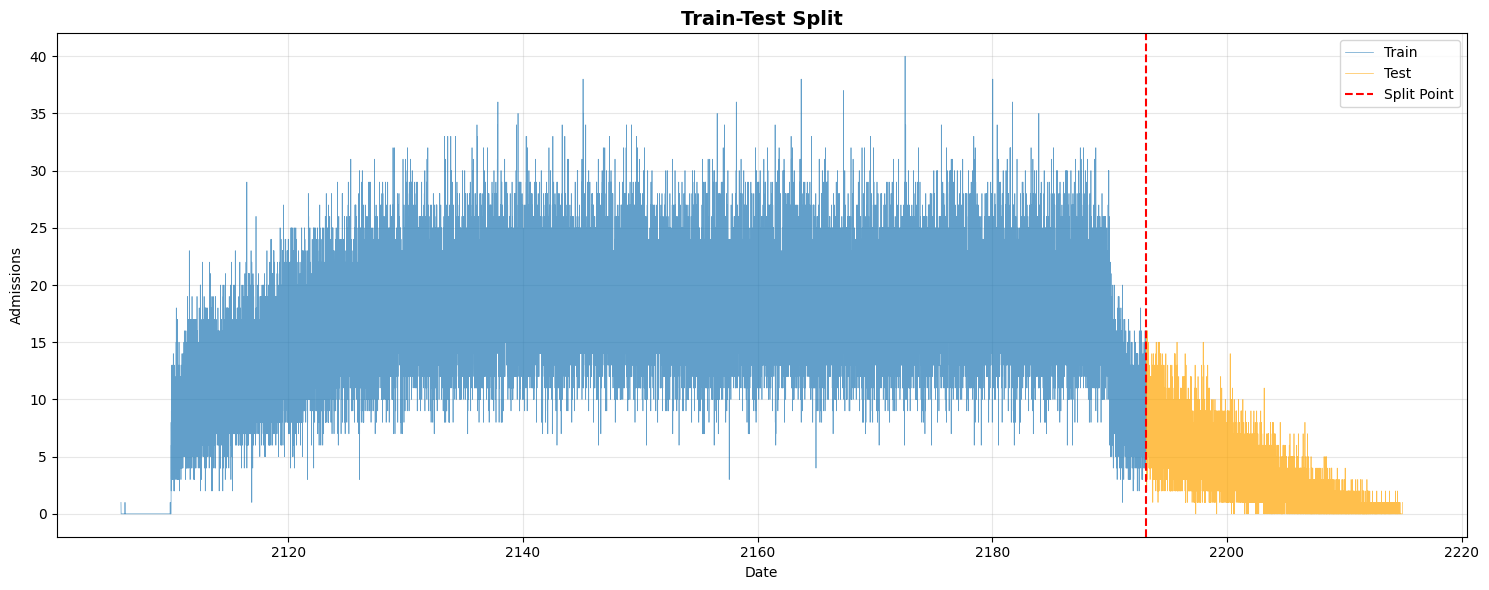

In [5]:
if len(target_series) > 0:
    train_size = int(len(target_series) * TRAIN_TEST_SPLIT)
    train_data = target_series[:train_size]
    test_data = target_series[train_size:]
    print(f"Train set: {len(train_data)} days ({train_data.index.min()} to {train_data.index.max()})")
    print(f"Test set: {len(test_data)} days ({test_data.index.min()} to {test_data.index.max()})")
    print(f"Train/Test split: {len(train_data)}/{len(test_data)} = {TRAIN_TEST_SPLIT:.1%}")
    plt.figure(figsize=(15, 6))
    plt.plot(train_data.index, train_data.values, label='Train', alpha=0.7, linewidth=0.5)
    plt.plot(test_data.index, test_data.values, label='Test', alpha=0.7, linewidth=0.5, color='orange')
    plt.axvline(x=train_data.index[-1], color='red', linestyle='--', label='Split Point')
    plt.title('Train-Test Split', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Admissions')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    save_plot(plt.gcf(), 'train_test_split.png', RESULTS_PATH, DRIVE_RESULTS_PATH, dpi=300, bbox_inches='tight')
    plt.show()
else:
    train_data = pd.Series(dtype=float)
    test_data = pd.Series(dtype=float)


## Baseline Models

We'll start with simple baseline models to establish a performance benchmark.


1. Training Naive Forecast...
2. Training Seasonal Naive Forecast (7-day seasonality)...
3. Training Moving Average Forecast (30-day window)...

✓ Baseline models trained. Forecast horizon: 7977 days
✓ Saved plot to local: /content/hospital_admissions_forecasting/results/visualizations/model_development/baseline_forecasts.png
✓ Saved plot to Google Drive: /content/drive/MyDrive/hospital_admissions_forecasting/results/visualizations/model_development/baseline_forecasts.png


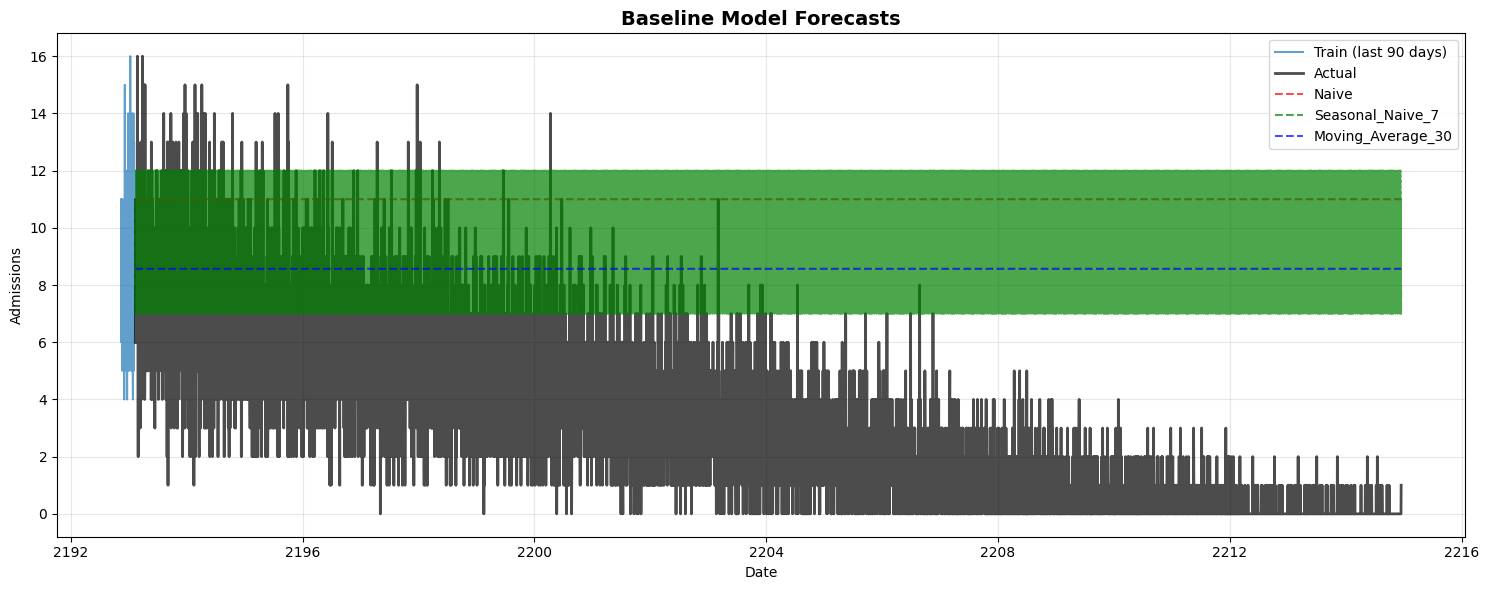

✓ Saved to local: /content/hospital_admissions_forecasting/models/baseline_forecasts.csv
✓ Saved to Google Drive: /content/drive/MyDrive/hospital_admissions_forecasting/models/baseline_forecasts.csv


In [6]:
baseline_forecasts = {}
if len(train_data) > 0 and len(test_data) > 0:
    horizon = len(test_data)
    print("1. Training Naive Forecast...")
    naive_pred = naive_forecast(train_data, horizon)
    baseline_forecasts['Naive'] = pd.Series(naive_pred, index=test_data.index)
    print("2. Training Seasonal Naive Forecast (7-day seasonality)...")
    if len(train_data) >= 7:
        seasonal_naive_pred = seasonal_naive_forecast(train_data, horizon, season_length=7)
        baseline_forecasts['Seasonal_Naive_7'] = pd.Series(seasonal_naive_pred, index=test_data.index)
    else:
        print("   Skipped: Insufficient data for seasonal naive")
    print("3. Training Moving Average Forecast (30-day window)...")
    if len(train_data) >= 30:
        ma_pred = moving_average_forecast(train_data, horizon, window=30)
        baseline_forecasts['Moving_Average_30'] = pd.Series(ma_pred, index=test_data.index)
    else:
        print("   Skipped: Insufficient data for moving average")
    print(f"\n✓ Baseline models trained. Forecast horizon: {horizon} days")
    plt.figure(figsize=(15, 6))
    plt.plot(train_data.index[-90:], train_data.values[-90:], label='Train (last 90 days)', alpha=0.7)
    plt.plot(test_data.index, test_data.values, label='Actual', alpha=0.7, color='black', linewidth=2)
    colors = ['red', 'green', 'blue', 'purple']
    for i, (name, forecast) in enumerate(baseline_forecasts.items()):
        plt.plot(forecast.index, forecast.values, label=name, alpha=0.7, linestyle='--', color=colors[i % len(colors)])
    plt.title('Baseline Model Forecasts', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Admissions')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    save_plot(plt.gcf(), 'baseline_forecasts.png', RESULTS_PATH, DRIVE_RESULTS_PATH, dpi=300, bbox_inches='tight')
    plt.show()

    # Save baseline forecasts for evaluation
    baseline_forecasts_df = pd.DataFrame(baseline_forecasts)
    save_file(baseline_forecasts_df, 'baseline_forecasts.csv', MODELS_PATH, DRIVE_MODELS_PATH)
else:
    print("Insufficient data for baseline models")


## Model Evaluation

Calculate basic evaluation metrics to assess model performance.


In [7]:
# ============================================================================
# MODEL EVALUATION METRICS
# ============================================================================

if len(baseline_forecasts) > 0 and len(test_data) > 0:
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

    def calculate_mape(y_true, y_pred):
        """Calculate Mean Absolute Percentage Error."""
        mask = y_true != 0
        if mask.sum() == 0:
            return np.nan
        return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

    print("="*70)
    print("BASELINE MODELS - EVALUATION METRICS")
    print("="*70)
    print(f"\nTest period: {len(test_data)} days")
    print(f"Date range: {test_data.index.min()} to {test_data.index.max()}\n")

    results = {}

    for model_name, forecast in baseline_forecasts.items():
        # Align forecast with test_data
        forecast_aligned = forecast.reindex(test_data.index)

        # Remove NaN values for metric calculation
        mask = ~(forecast_aligned.isna() | test_data.isna())
        if mask.sum() == 0:
            print(f"⚠️  {model_name}: No valid data for evaluation")
            continue

        y_true = test_data[mask].values
        y_pred = forecast_aligned[mask].values

        # Calculate metrics
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mape = calculate_mape(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)

        results[model_name] = {
            'MAE': mae,
            'RMSE': rmse,
            'MAPE': mape,
            'R²': r2
        }

    # Display results in a table
    if results:
        print(f"{'Model':<25} {'MAE':<10} {'RMSE':<10} {'MAPE (%)':<12} {'R²':<10}")
        print("-"*70)
        for model_name, metrics in results.items():
            mape_str = f"{metrics['MAPE']:.2f}" if not np.isnan(metrics['MAPE']) else "N/A"
            print(f"{model_name:<25} {metrics['MAE']:<10.2f} {metrics['RMSE']:<10.2f} {mape_str:<12} {metrics['R²']:<10.4f}")

        # Find best model for each metric
        print("\n" + "="*70)
        print("BEST MODELS BY METRIC:")
        print("="*70)
        best_mae = min(results.items(), key=lambda x: x[1]['MAE'])
        best_rmse = min(results.items(), key=lambda x: x[1]['RMSE'])
        best_mape = min([(k, v) for k, v in results.items() if not np.isnan(v['MAPE'])],
                       key=lambda x: x[1]['MAPE'], default=(None, None))
        best_r2 = max(results.items(), key=lambda x: x[1]['R²'])

        print(f"Best MAE:  {best_mae[0]} ({best_mae[1]['MAE']:.2f})")
        print(f"Best RMSE: {best_rmse[0]} ({best_rmse[1]['RMSE']:.2f})")
        if best_mape[0]:
            print(f"Best MAPE: {best_mape[0]} ({best_mape[1]['MAPE']:.2f}%)")
        print(f"Best R²:  {best_r2[0]} ({best_r2[1]['R²']:.4f})")

        # Save results
        results_df = pd.DataFrame(results).T
        save_file(results_df, 'baseline_models_evaluation.csv', MODELS_PATH, DRIVE_MODELS_PATH)
        print(f"\n✓ Evaluation metrics saved to baseline_models_evaluation.csv")
    else:
        print("⚠️  No valid results to display")
else:
    print("⚠️  Cannot evaluate: No forecasts or test data available")


BASELINE MODELS - EVALUATION METRICS

Test period: 7977 days
Date range: 2193-02-11 00:00:00 to 2214-12-15 00:00:00

Model                     MAE        RMSE       MAPE (%)     R²        
----------------------------------------------------------------------
Naive                     7.95       8.47       355.22       -6.8833   
Seasonal_Naive_7          6.51       7.23       289.73       -4.7431   
Moving_Average_30         5.68       6.25       256.63       -3.3001   

BEST MODELS BY METRIC:
Best MAE:  Moving_Average_30 (5.68)
Best RMSE: Moving_Average_30 (6.25)
Best MAPE: Moving_Average_30 (256.63%)
Best R²:  Moving_Average_30 (-3.3001)
✓ Saved to local: /content/hospital_admissions_forecasting/models/baseline_models_evaluation.csv
✓ Saved to Google Drive: /content/drive/MyDrive/hospital_admissions_forecasting/models/baseline_models_evaluation.csv

✓ Evaluation metrics saved to baseline_models_evaluation.csv
